In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Data_Engineering_Internship/student_performance.csv')
conn = sqlite3.connect(':memory:')
df.to_sql('students', conn, index=False, if_exists='replace')

print(df.columns.tolist())
df.head()

['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [4]:
df1 = pd.read_sql_query("""
    SELECT department, ROUND(AVG(math_score), 1) AS avg_math
    FROM students
    GROUP BY department
    ORDER BY avg_math DESC""", conn)

df2 = pd.read_sql_query("""
    SELECT department, COUNT(*) AS student_count
    FROM students
    GROUP BY department""", conn)

df3 = pd.read_sql_query("""
    SELECT name, (math_score + programming_score + science_score + english_score) AS total_score
    FROM students
    ORDER BY total_score DESC
    LIMIT 8""", conn)

df4 = pd.read_sql_query("""
    SELECT gender, ROUND(AVG(attendance_percentage), 1) AS avg_attendance
    FROM students
    GROUP BY gender """, conn)

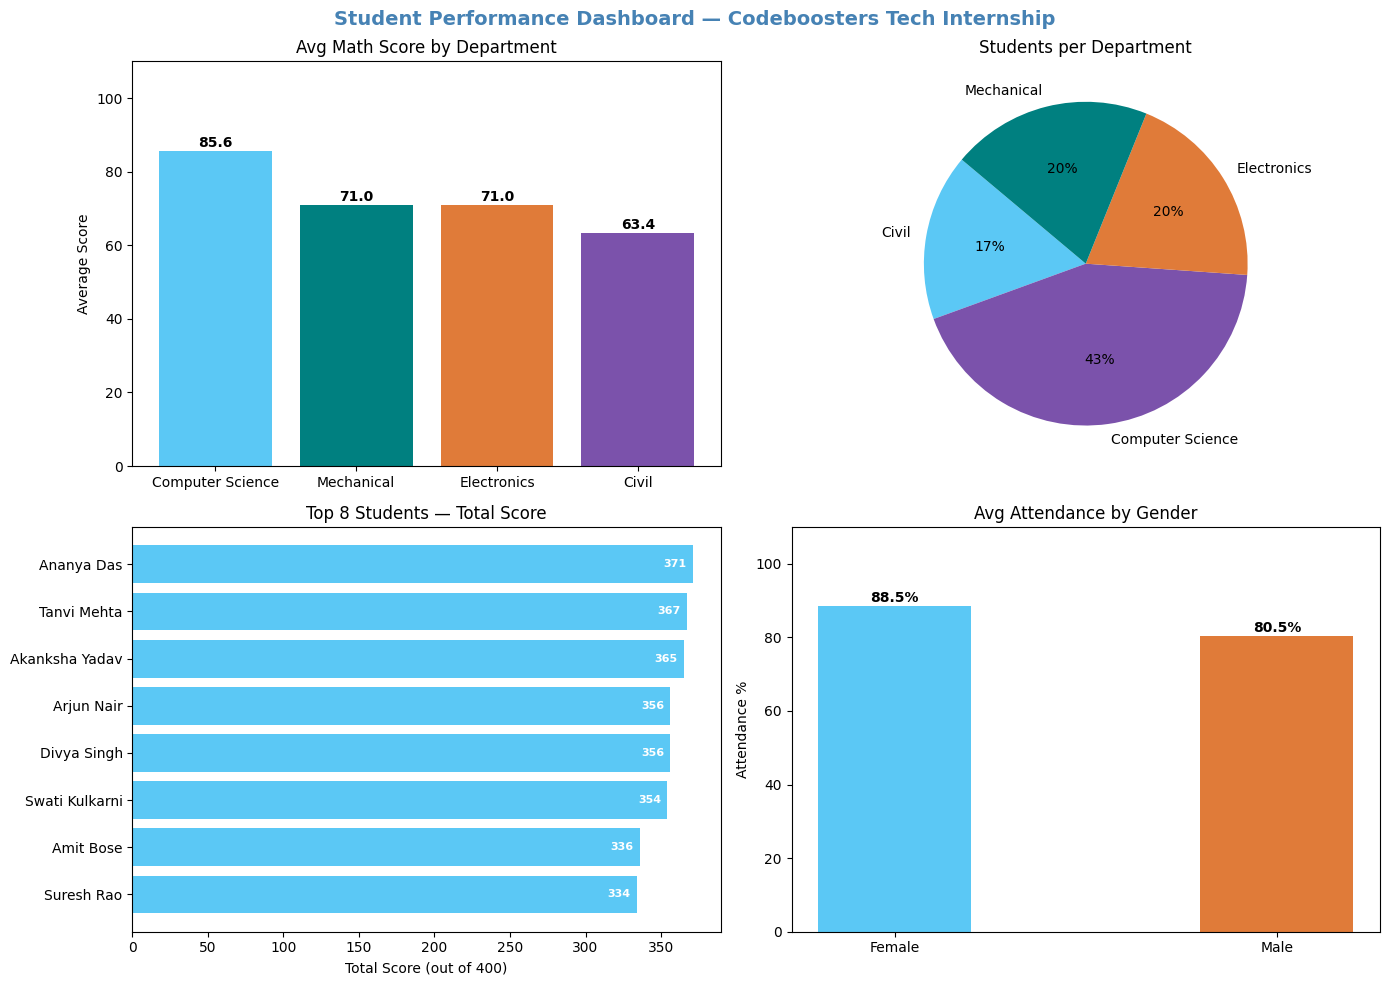

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Performance Dashboard — Codeboosters Tech Internship',
             fontsize=14, fontweight='bold', color='steelblue')

ax1 = axes[0, 0]
bars1 = ax1.bar(df1['department'], df1['avg_math'],
                color=['#5BC8F5','#008080','#E07B39','#7B52AB'])
ax1.set_title('Avg Math Score by Department')
ax1.set_ylabel('Average Score')
ax1.set_ylim(0, 110)
for bar, val in zip(bars1, df1['avg_math']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')

ax2 = axes[0, 1]
ax2.pie(df2['student_count'], labels=df2['department'], autopct='%1.0f%%',
        colors=['#5BC8F5','#7B52AB','#E07B39','#008080'], startangle=140)
ax2.set_title('Students per Department')

ax3 = axes[1, 0]
df3_rev = df3.iloc[::-1].reset_index(drop=True)
ax3.barh(df3_rev['name'], df3_rev['total_score'], color='#5BC8F5')
ax3.set_title('Top 8 Students — Total Score')
ax3.set_xlabel('Total Score (out of 400)')
for i, val in enumerate(df3_rev['total_score']):
    ax3.text(val - 4, i, str(val), va='center', ha='right',
             fontweight='bold', color='white', fontsize=8)

ax4 = axes[1, 1]
bars4 = ax4.bar(df4['gender'], df4['avg_attendance'],
                color=['#5BC8F5','#E07B39'], width=0.4)
ax4.set_title('Avg Attendance by Gender')
ax4.set_ylabel('Attendance %')
ax4.set_ylim(0, 110)
for bar, val in zip(bars4, df4['avg_attendance']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('student_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()